<a href="https://colab.research.google.com/github/kamat-v/qc-course-materials/blob/main/notebooks/week02_single_qubit_systems.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Working with single-qubit systems in Qiskit

In [ ]:
!pip install qiskit qiskit_aer qiskit-ibm-runtime pylatexenc

In [ ]:
from qiskit import QuantumCircuit
import numpy as np
import matplotlib.pyplot as plt

**1. An example of a quantum circuit**

In [ ]:
circuit=QuantumCircuit(1) #Creating an empty, one-qubit circuit

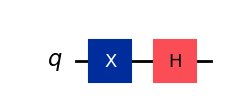

In [ ]:
circuit.x(0) #Apply an X gate
circuit.h(0) #Apply an H gate
circuit.draw("mpl") #Display

**2. Another example -- the phase shift gate $P(\theta)$**


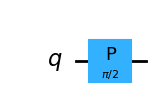

In [ ]:
circuit_two=QuantumCircuit(1)
circuit_two.p(np.pi/2,0)
circuit_two.draw("mpl")

**3. Simulating state evolution**

Let us simulate the evolution of the state vector by a quantum circuit.

In [ ]:
from qiskit.quantum_info import Statevector

In [ ]:
state=Statevector(circuit)
print(state)

Statevector([ 0.70710678+0.j, -0.70710678+0.j],
            dims=(2,))


In [ ]:
state_two=Statevector(circuit_two)
print(state_two)


Statevector([1.+0.j, 0.+0.j],
            dims=(2,))


**4. Getting measurement samples from a simulator**

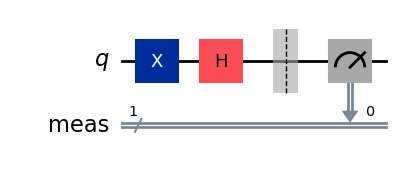

In [ ]:
circuit.measure_all()
circuit.draw("mpl")

In [ ]:
from qiskit_aer import AerSimulator
backend=AerSimulator(seed_simulator=18620123)

In [ ]:
from qiskit_ibm_runtime import SamplerV2 as Sampler
sampler=Sampler(backend)

In [ ]:
job=sampler.run([circuit], shots=1024) # sample any number of times
result=job.result()[0].data.meas # Getting the results
print(result.get_counts())

{'0': 505, '1': 519}
